In [ ]:
from google.colab import files
uploaded = files.upload()

Saving h1 data.xlsx to h1 data.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel("h1 data.xlsx")

data.head()

,Batch_ID,Granulation_Time,Binder_Amount,Drying_Temp,Drying_Time,Compression_Force,Machine_Speed,Lubricant_Conc,Moisture_Content,Tablet_Weight,Hardness,Friability,Disintegration_Time,Dissolution_Rate,Content_Uniformity
0,T001,15,8.5,60,25,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7
1,T002,12,7.0,65,20,15.0,120,0.8,2.8,201.3,110,0.45,12.1,87.9,101.2
2,T003,18,9.2,55,30,10.8,180,1.2,1.9,198.5,85,0.78,6.8,91.5,97.3
3,T004,20,10.0,58,35,8.5,200,1.5,1.5,203.2,72,0.95,5.5,93.8,95.9
4,T005,10,6.5,70,18,16.2,100,0.6,3.2,202.7,125,0.38,14.8,85.1,103.5


In [ ]:
data.shape

(60, 15)

In [ ]:
data["Energy_Index"] = (
    0.4 * data["Machine_Speed"] +
    0.3 * data["Compression_Force"] +
    0.3 * data["Drying_Temp"]
)

In [ ]:
targets = [
"Dissolution_Rate",
"Hardness",
"Content_Uniformity",
"Tablet_Weight",
"Friability",
"Energy_Index"
]

In [ ]:
X = data.drop(columns=["Batch_ID"] + targets)
y = data[targets]

In [ ]:
X.head()

,Granulation_Time,Binder_Amount,Drying_Temp,Drying_Time,Compression_Force,Machine_Speed,Lubricant_Conc,Moisture_Content,Disintegration_Time
0,15,8.5,60,25,12.5,150,1.0,2.1,8.2
1,12,7.0,65,20,15.0,120,0.8,2.8,12.1
2,18,9.2,55,30,10.8,180,1.2,1.9,6.8
3,20,10.0,58,35,8.5,200,1.5,1.5,5.5
4,10,6.5,70,18,16.2,100,0.6,3.2,14.8


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=6)

selector.fit(X, y.mean(axis=1))

selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['Granulation_Time', 'Binder_Amount', 'Drying_Temp', 'Drying_Time',
       'Compression_Force', 'Moisture_Content'],
      dtype='object')


In [ ]:
X = X[selected_features]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4
    )
)

model.fit(X_train,y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    XGBRegressor(),
    X,
    y["Dissolution_Rate"],
    cv=5,
    scoring="r2"
)

print("Cross-validation score:", scores.mean())

Cross-validation score: 0.9581876623284122


In [ ]:
pred = model.predict(X_test)

pred[:5]

array([[ 89.480545  ,  94.994736  ,  98.69102   , 200.38939   ,
          0.6397422 ,  84.23112   ],
       [ 90.38617   ,  92.23223   ,  98.591896  , 200.50093   ,
          0.71323156,  86.30483   ],
       [ 86.72302   , 110.53626   , 101.29098   , 201.6381    ,
          0.45312923,  72.00314   ],
       [ 87.18713   , 112.0379    , 101.90599   , 202.09601   ,
          0.47666228,  74.24881   ],
       [ 97.80011   ,  54.970882  ,  92.90221   , 207.19728   ,
          1.3502054 , 110.73169   ]], dtype=float32)

In [ ]:
from sklearn.metrics import r2_score
for i, target in enumerate(y.columns):

    score = r2_score(y_test.iloc[:, i], pred[:, i])

    print(target, "R2:", score)


Dissolution_Rate R2: 0.9694414663376475
Hardness R2: 0.9846802353858948
Content_Uniformity R2: 0.9824070585096473
Tablet_Weight R2: 0.919874108098369
Friability R2: 0.9887916944550611
Energy_Index R2: 0.9836292496250307


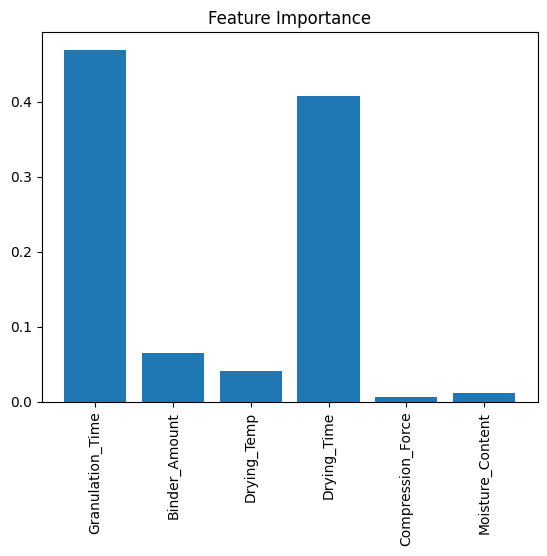

In [ ]:
import matplotlib.pyplot as plt

importance = model.estimators_[0].feature_importances_

plt.bar(X.columns,importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def recommend_parameters(model, current_input, feature_ranges, trials=200):

    best_score = -1e9
    best_params = None
    best_pred = None

    for _ in range(trials):

        candidate = current_input.copy()

        for f in feature_ranges:
            candidate[f] = np.random.uniform(
                feature_ranges[f][0],
                feature_ranges[f][1]
            )

        pred = model.predict(pd.DataFrame([candidate]))[0]

        dissolution = pred[0]
        energy = pred[5]

        score = dissolution - 0.1 * energy

        if score > best_score:
            best_score = score
            best_params = candidate
            best_pred = pred

    return best_params, best_pred

In [ ]:
feature_ranges = {
    "Granulation_Time": (5,20),
    "Binder_Amount": (2,10),
    "Drying_Temp": (40,80),
    "Compression_Force": (5,15),
    "Moisture_Content": (1,5)
}

In [ ]:
current = X.iloc[0].to_dict()

best_params, pred = recommend_parameters(
    model,
    current,
    feature_ranges
)

print("Recommended Parameters:")
print(best_params)

print("\nPredicted Output:")
print(pred)

Recommended Parameters:
{'Granulation_Time': 19.633829378615633, 'Binder_Amount': 7.040835321750645, 'Drying_Temp': 74.41000202559479, 'Drying_Time': 25.0, 'Compression_Force': 9.267157472276896, 'Moisture_Content': 1.7827343275569274}

Predicted Output:
[ 93.52662    83.2318     97.13275   197.95741     0.7753284  87.99508  ]


In [ ]:
recommend(data.iloc[2])

'Increase drying temperature for better dissolution'

In [ ]:
import numpy as np

solutions = []

for temp in range(55,70):
    for speed in range(120,180):

        sample = X.mean().copy()

        if "Drying_Temp" in sample:
            sample["Drying_Temp"] = temp

        if "Machine_Speed" in sample:
            sample["Machine_Speed"] = speed

        pred = model.predict(sample.values.reshape(1,-1))[0]

        solutions.append({
            "Temp":temp,
            "Speed":speed,
            "Quality":pred[0],
            "Yield":pred[3],
            "Energy":pred[5]
        })

solutions_df = pd.DataFrame(solutions)
solutions_df.head()

,Temp,Speed,Quality,Yield,Energy
0,55,120,90.646896,199.566605,93.292404
1,55,121,90.646896,199.566605,93.292404
2,55,122,90.646896,199.566605,93.292404
3,55,123,90.646896,199.566605,93.292404
4,55,124,90.646896,199.566605,93.292404


In [ ]:

pareto_points = []

for i, row in solutions_df.iterrows():

    dominated = False

    for j, row2 in solutions_df.iterrows():

        if (
            row2["Dissolution"] >= row["Dissolution"] and
            row2["Energy"] <= row["Energy"] and
            (row2["Dissolution"] > row["Dissolution"] or row2["Energy"] < row["Energy"])
        ):
            dominated = True
            break

    if not dominated:
        pareto_points.append(row)

pareto_df = pd.DataFrame(pareto_points)

In [ ]:
pareto_df.sort_values(
    ["Dissolution","Energy"],
    ascending=[False,True]
).head()

,Drying_Temp,Moisture_Content,Dissolution,Hardness,Energy
30,58.0,1.500000,90.107605,93.343193,92.792587
31,58.0,1.722222,90.107605,93.343193,92.792587
32,58.0,1.944444,90.107605,93.343193,92.792587
70,62.0,1.500000,89.975784,93.358238,84.814865
71,62.0,1.722222,89.975784,93.358238,84.814865


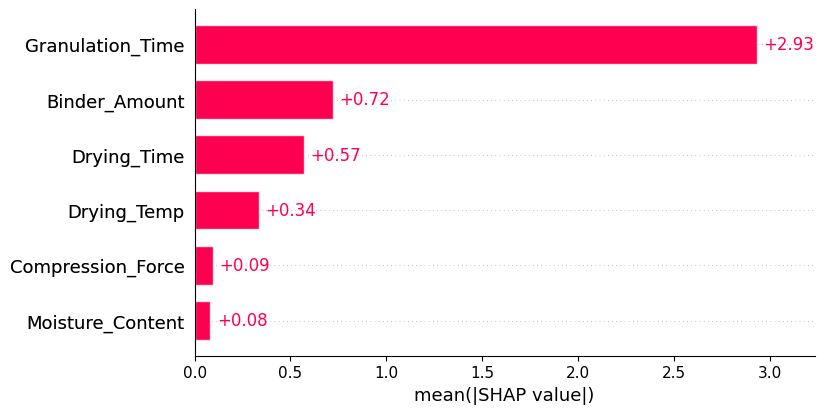

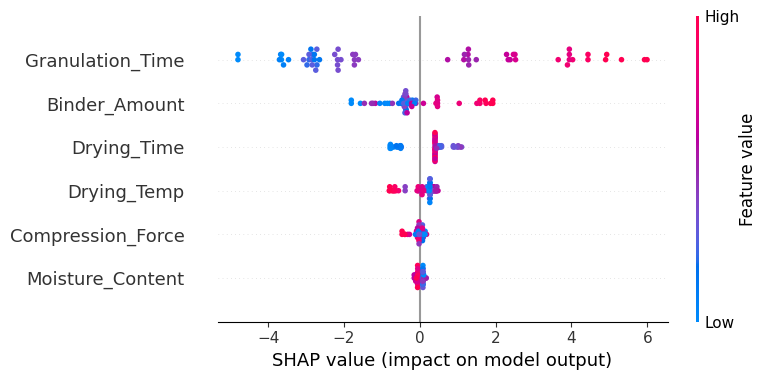

In [ ]:
import shap

explainer = shap.Explainer(model.estimators_[0])

shap_values = explainer(X)

shap.plots.bar(shap_values)
shap.summary_plot(shap_values, X)

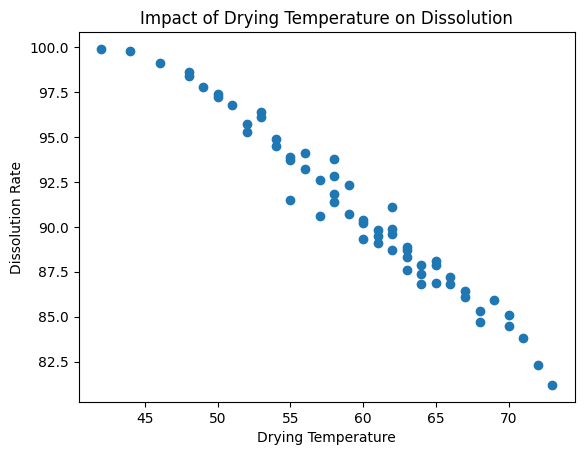

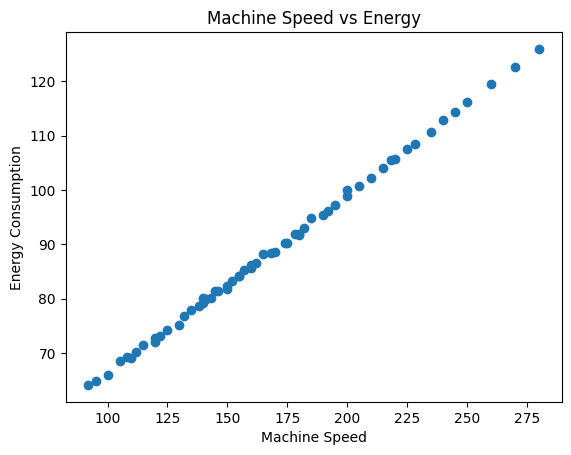

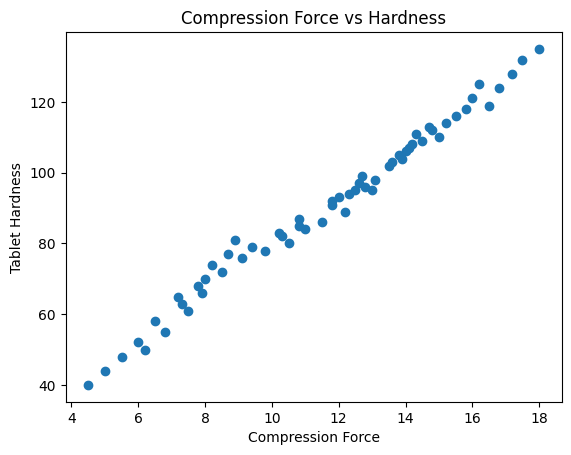

In [ ]:
import matplotlib.pyplot as plt

# Drying Temperature vs Dissolution
plt.scatter(data["Drying_Temp"], data["Dissolution_Rate"])
plt.xlabel("Drying Temperature")
plt.ylabel("Dissolution Rate")
plt.title("Impact of Drying Temperature on Dissolution")
plt.show()


# Machine Speed vs Energy
plt.scatter(data["Machine_Speed"], data["Energy_Index"])
plt.xlabel("Machine Speed")
plt.ylabel("Energy Consumption")
plt.title("Machine Speed vs Energy")
plt.show()


# Compression Force vs Hardness
plt.scatter(data["Compression_Force"], data["Hardness"])
plt.xlabel("Compression Force")
plt.ylabel("Tablet Hardness")
plt.title("Compression Force vs Hardness")
plt.show()

In [ ]:
def forecast_process(params):

    sample = pd.DataFrame([params])

    sample = sample[selected_features]

    pred = model.predict(sample)[0]

    return {
        "Dissolution_Rate": pred[0],
        "Hardness": pred[1],
        "Content_Uniformity": pred[2],
        "Tablet_Weight": pred[3],
        "Friability": pred[4],
        "Energy_Index": pred[5]
    }

In [ ]:
forecast_process({
    "Granulation_Time":15,
    "Binder_Amount":8,
    "Drying_Temp":60,
    "Drying_Time":25,
    "Compression_Force":12,
    "Moisture_Content":2
})

{'Dissolution_Rate': np.float32(89.96288),
 'Hardness': np.float32(93.34319),
 'Content_Uniformity': np.float32(98.83666),
 'Tablet_Weight': np.float32(200.07649),
 'Friability': np.float32(0.69098425),
 'Energy_Index': np.float32(84.814865)}

In [ ]:
def simulate_scenario(base_params, new_params):

    base_pred = forecast_process(base_params)

    scenario_pred = forecast_process(new_params)

    print("Current Process Results")
    print("----------------------")

    for k,v in base_pred.items():
        print(f"{k}: {v:.2f}")

    print("\nScenario Results")
    print("----------------")

    for k,v in scenario_pred.items():
        print(f"{k}: {v:.2f}")

    print("\nImpact of Change")
    print("----------------")

    for key in base_pred:

        diff = scenario_pred[key] - base_pred[key]

        print(f"{key}: {diff:+.2f}")

In [ ]:
base_params = {
    "Granulation_Time":15,
    "Binder_Amount":8,
    "Drying_Temp":58,
    "Drying_Time":25,
    "Compression_Force":10,
    "Moisture_Content":3
}

scenario_params = {
    "Granulation_Time":15,
    "Binder_Amount":8,
    "Drying_Temp":62,
    "Drying_Time":25,
    "Compression_Force":10,
    "Moisture_Content":3
}

simulate_scenario(base_params, scenario_params)

Current Process Results
----------------------
Dissolution_Rate: 89.58
Hardness: 94.60
Content_Uniformity: 98.93
Tablet_Weight: 199.63
Friability: 0.68
Energy_Index: 91.96

Scenario Results
----------------
Dissolution_Rate: 89.45
Hardness: 94.62
Content_Uniformity: 99.02
Tablet_Weight: 199.64
Friability: 0.68
Energy_Index: 83.19

Impact of Change
----------------
Dissolution_Rate: -0.13
Hardness: +0.02
Content_Uniformity: +0.10
Tablet_Weight: +0.01
Friability: +0.00
Energy_Index: -8.77


In [ ]:
import numpy as np

solutions = []

for temp in range(55,70):
    for moisture in np.linspace(1.5,3.5,10):

        params = {
            "Granulation_Time":15,
            "Binder_Amount":8,
            "Drying_Temp":temp,
            "Drying_Time":25,
            "Compression_Force":12,
            "Moisture_Content":moisture
        }

        pred = forecast_process(params)

        solutions.append({
            "Drying_Temp": temp,
            "Moisture_Content": moisture,
            "Dissolution": pred["Dissolution_Rate"],
            "Hardness": pred["Hardness"],
            "Energy": pred["Energy_Index"]
        })

solutions_df = pd.DataFrame(solutions)

In [ ]:
solutions_df.sort_values(
    ["Dissolution","Energy"],
    ascending=[False,True]
).head(10)

,Drying_Temp,Moisture_Content,Dissolution,Hardness,Energy
30,58,1.500000,90.107605,93.343193,92.792587
31,58,1.722222,90.107605,93.343193,92.792587
32,58,1.944444,90.107605,93.343193,92.792587
70,62,1.500000,89.975784,93.358238,84.814865
71,62,1.722222,89.975784,93.358238,84.814865
72,62,1.944444,89.975784,93.358238,84.814865
80,63,1.500000,89.975784,93.358238,84.814865
81,63,1.722222,89.975784,93.358238,84.814865
82,63,1.944444,89.975784,93.358238,84.814865
40,59,1.500000,89.962883,93.343193,84.814865


In [ ]:
pred = forecast_process({
    "Granulation_Time":15,
    "Binder_Amount":8,
    "Drying_Temp":58,
    "Drying_Time":25,
    "Compression_Force":10,
    "Moisture_Content":3
})

recommend(pred)

['Increase Drying_Temp by 2°C']

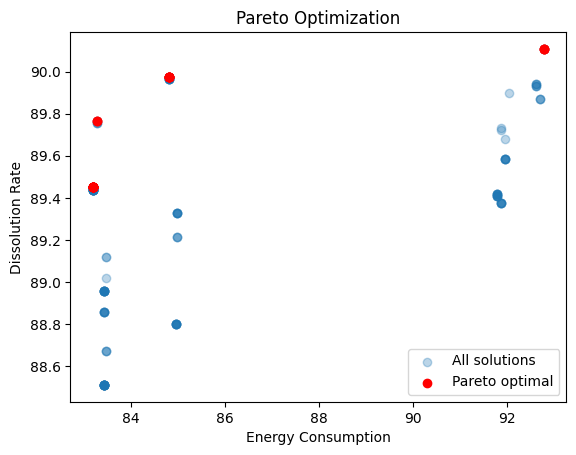

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    solutions_df["Energy"],
    solutions_df["Dissolution"],
    alpha=0.3,
    label="All solutions"
)

plt.scatter(
    pareto_df["Energy"],
    pareto_df["Dissolution"],
    color="red",
    label="Pareto optimal"
)

plt.xlabel("Energy Consumption")
plt.ylabel("Dissolution Rate")
plt.title("Pareto Optimization")

plt.legend()

plt.show()

In [ ]:
def detect_risk(pred):

    if pred["Friability"] > 1:
        return "Tablet breakage risk"

    if pred["Hardness"] < 70:
        return "Low tablet strength"

    return "Process stable"

In [ ]:
pred = forecast_process({
    "Granulation_Time":15,
    "Binder_Amount":8,
    "Drying_Temp":58,
    "Drying_Time":25,
    "Compression_Force":10,
    "Moisture_Content":3
})

print(pred)

print(detect_risk(pred))

{'Dissolution_Rate': np.float32(89.58395), 'Hardness': np.float32(94.60147), 'Content_Uniformity': np.float32(98.92545), 'Tablet_Weight': np.float32(199.6348), 'Friability': np.float32(0.678162), 'Energy_Index': np.float32(91.95948)}
Process stable
